<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Region%20Analysis%20using%20K-Means%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Set random seed for reproducibility and styling
np.random.seed(42)
sns.set_theme(style="whitegrid")

In [8]:
#1.Generate Synthetic Kenyan Regional Data
# Realistic features for Kenyan counties based on KNBS (Kenya National Bureau of Statistics) trends
data = {
    'County': ['Nairobi', 'Mombasa', 'Uasin Gishu', 'Nakuru', 'Kiambu', 'Turkana', 'Wajir', 'Kakamega', 'Meru', 'Kilifi'],
    'Population_Density_per_sqkm': [7000, 3000, 250, 300, 800, 15, 12, 400, 350, 150],
    'Avg_Household_Income_KES': [85000, 60000, 45000, 42000, 55000, 18000, 16000, 30000, 38000, 25000],
    'Annual_Food_Production_Tons': [5000, 8000, 600000, 450000, 350000, 15000, 12000, 200000, 280000, 90000]

}

df = pd.DataFrame(data)
print("---Original Kenyan County Data---")
print(df.to_string(index=False),"\n")

---Original Kenyan County Data---
     County  Population_Density_per_sqkm  Avg_Household_Income_KES  Annual_Food_Production_Tons
    Nairobi                         7000                     85000                         5000
    Mombasa                         3000                     60000                         8000
Uasin Gishu                          250                     45000                       600000
     Nakuru                          300                     42000                       450000
     Kiambu                          800                     55000                       350000
    Turkana                           15                     18000                        15000
      Wajir                           12                     16000                        12000
   Kakamega                          400                     30000                       200000
       Meru                          350                     38000                       280000
     K

In [9]:
# 2. PREPROCESSING & K-MEANS CLUSTERING
# ==========================================
# Features for clustering
features = ['Population_Density_per_sqkm','Avg_Household_Income_KES','Annual_Food_Production_Tons']
X = df[features]

# standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Apply K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
# ==========================================
# # 3. CLUSTER ANALYSIS & INTERPRETATION
# # ==========================================
# Calculate cluster centroids (averages) to understand each group
cluster_profiles = df.groupby('Cluster')[features].mean().round(0)
print("---Cluster Profiles(Averages)--")
print(cluster_profiles,"\n")

# Map clusters to meaningful Kenyan regional archetypes based on the data
def map_persona(row):
  density = row['Population_Density_per_sqkm']
  income = row['Avg_Household_Income_KES']
  production = row['Annual_Food_Production_Tons']

  if density > 1000 and production < 2000:
    return "Urban Commercial Hubs"
  elif production > 200000 and density < 1000:
    return "Agricultural Heartlands"
  else:
    return "Arid & Emerging Regions(ASALs)"
df['Regional_Archetype'] = df.apply(map_persona,axis=1)

---Cluster Profiles(Averages)--
         Population_Density_per_sqkm  Avg_Household_Income_KES  \
Cluster                                                          
0                             5000.0                   72500.0   
1                              425.0                   45000.0   
2                              144.0                   22250.0   

         Annual_Food_Production_Tons  
Cluster                               
0                             6500.0  
1                           420000.0  
2                            79250.0   



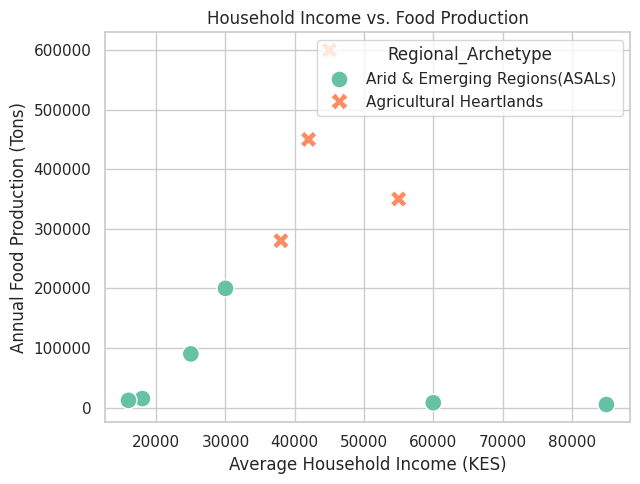

In [13]:
#4.Visualization
plt.figure(figsize=(12,5))

#Plot 1: Income vs Food Production
plt.subplot(1,2,1)
sns.scatterplot(x='Avg_Household_Income_KES',y='Annual_Food_Production_Tons',hue='Regional_Archetype',style='Regional_Archetype',data=df,palette='Set2',s=150)

plt.title('Household Income vs. Food Production')
plt.xlabel('Average Household Income (KES)')
plt.ylabel('Annual Food Production (Tons)')

plt.tight_layout()
plt.show()